# Taller 4 — Sistema de Recuperación de Información
**Asignatura:** Minería de Datos | **Código:** 2016325

## Objetivo
Ampliar la aplicación del Taller 2 con un sistema de búsqueda que permita
recuperar artículos científicos de la revista MAKE (MDPI) mediante consultas
en lenguaje natural, aplicando procesamiento de texto, representación
vectorial, reducción de dimensionalidad y ranking de relevancia.

---

## 1. Construcción del corpus (§4.1)

### Campos utilizados para representar cada artículo
- **Título** (×3): se repite 3 veces para ponderar su importancia relativa.
- **Abstract**: texto principal del artículo.
- **topic_label** (respaldo): solo si el abstract estuviera ausente. En este
  caso no fue necesario pues todos los artículos tienen abstract completo.

### Estadísticas del corpus real

| Campo | Total | Sin datos |
|---|---|---|
| Artículos totales | 217 | — |
| Sin título | 0 | 0% |
| Sin abstract | 0 | **0%** |
| Sin topic_label | 0 | 0% |

### Distribución por año

| Año | Artículos | Abstracts disponibles |
|---|---|---|
| 2025 (Vol. 7) | 70 | 70 (100%) — scraping con rvest en R |
| 2026 (Vol. 8) | 147 | 147 (100%) — completados con API de Crossref |

### Distribución por temática

| Tema | Artículos |
|---|---|
| Machine Learning | 170 (78.3%) |
| IA Generativa | 34 (15.7%) |
| Estadística | 13 (6.0%) |

### Tratamiento de valores faltantes

Inicialmente 156 artículos del Volumen 8 (2026) no tenían abstract, ya que
las APIs de Crossref y OpenAlex no los devolvieron en la primera recolección.
Estos se completaron posteriormente ejecutando el script `completar_abstracts.py`,
que consulta la API de Crossref por DOI y recuperó el abstract del 100% de los
artículos faltantes (156/156). Los abstracts vienen con etiquetas JATS
(ej: `<jats:p>`) que se limpian con expresiones regulares antes de
almacenarlos en la base SQLite.

**No se reemplazaron textos faltantes por contenido inventado**, conforme
a las instrucciones del taller. Todos los abstracts provienen directamente
de Crossref, que los recibe de MDPI como parte del proceso de indexación.

### Criterios de inclusión/exclusión
- Se incluyen **todos los artículos** con al menos título (217/217).
- No se aplica filtro por idioma: todos los artículos de MAKE son en inglés
  por política editorial de la revista.
- Longitud promedio del corpus por documento: **1873 caracteres**.

### Impacto en el sistema de recuperación
Con el corpus 100% completo, todos los artículos tienen representaciones
vectoriales ricas basadas en su abstract real. Esto mejora significativamente
la calidad del buscador respecto a usar únicamente el topic_label como respaldo.

In [2]:
import sqlite3, pandas as pd
from buscador import construir_corpus, limpiar_texto

con = sqlite3.connect("make_q1_2025.sqlite")
df  = pd.read_sql_query("SELECT * FROM papers", con)
con.close()

print(f"Total artículos: {len(df)}")
print(f"Sin título:    {df['title'].isna().sum()}")
sin_abs = df['abstract'].isna().sum() + (df['abstract'].fillna('').str.strip() == '').sum()
print(f"Sin abstract:  {sin_abs} ({sin_abs/len(df)*100:.1f}%)")
print(f"Sin topic:     {df['topic_label'].isna().sum()}")
print()
print("Distribución por año:")
print(df.groupby('year').size().to_string())
print()
print("Distribución por temática:")
print(df['topic_label'].value_counts().to_string())
print()

# Construir corpus
corpus, ids = construir_corpus(df)
print(f"Artículos incluidos en el corpus: {len(corpus)}")
lens = [len(c) for c in corpus]
print(f"Longitud promedio del corpus: {sum(lens)/len(lens):.0f} chars")
print()

# Cuántos usan solo topic_label como respaldo
n_sin_abs = df['abstract'].fillna('').str.strip().eq('').sum()
print(f"Artículos representados con topic_label (sin abstract): {n_sin_abs}")
print("NOTA: estos artículos tienen representaciones vectoriales pobres.")

Total artículos: 217
Sin título:    0
Sin abstract:  0 (0.0%)
Sin topic:     0

Distribución por año:
year
2025     70
2026    147

Distribución por temática:
topic_label
Machine Learning    170
IA Generativa        34
Estadística          13

Artículos incluidos en el corpus: 217
Longitud promedio del corpus: 1873 chars

Artículos representados con topic_label (sin abstract): 0
NOTA: estos artículos tienen representaciones vectoriales pobres.


El corpus está compuesto por 217 artículos de la revista MAKE, todos con título, abstract y categoría temática disponibles (0 faltantes en ningún campo). Los artículos provienen de dos años: 70 del Volumen 7 (2025), recolectados mediante scraping en R con rvest, y 147 del Volumen 8 (2026), obtenidos con Selenium y las APIs de Crossref y OpenAlex. Los abstracts faltantes de 2026 se completaron posteriormente usando la API de Crossref, logrando cobertura total. En cuanto a la temática, Machine Learning domina con 170 artículos (78.3%), seguido de IA Generativa con 34 (15.7%) y Estadística con 13 (6.0%). La longitud promedio del corpus por documento es de 1873 caracteres, lo que indica textos suficientemente ricos para la representación vectorial. Todos los 217 artículos se incluyeron en el corpus sin exclusiones.

In [3]:
# Construir corpus
corpus, ids = construir_corpus(df)
print(f"Artículos incluidos en el corpus: {len(corpus)}")
print()
print("Longitud del corpus (caracteres):")
lens = [len(c) for c in corpus]
print(f"  mín: {min(lens)} | máx: {max(lens)} | promedio: {sum(lens)/len(lens):.0f}")
print()
print("Ejemplo de documento procesado (primeros 300 chars):")
print(corpus[0][:300])

Artículos incluidos en el corpus: 217

Longitud del corpus (caracteres):
  mín: 952 | máx: 3509 | promedio: 1873

Ejemplo de documento procesado (primeros 300 chars):
ximed a dual loop evaluation framework integrating predictive model and human centered approaches for explainable ai in medical imaging ximed a dual loop evaluation framework integrating predictive model and human centered approaches for explainable ai in medical imaging ximed a dual loop evaluation


### Construcción del corpus

El corpus se construyó combinando el título (repetido 3 veces para darle mayor
peso) y el abstract de cada artículo. Se incluyeron los **217 artículos**
disponibles en la base SQLite, sin excluir ninguno.

**Estadísticas del corpus procesado:**

| Métrica | Valor |
|---|---|
| Artículos incluidos | 217 |
| Longitud mínima | 952 caracteres |
| Longitud máxima | 3509 caracteres |
| Longitud promedio | 1873 caracteres |

**Ejemplo de documento procesado (primeros 300 caracteres):**

In [5]:
# Verificación de idiomas en el corpus
# Se usa langdetect para identificar el idioma de cada abstract
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42  # reproducibilidad
    
    def detectar_idioma(texto):
        try:
            return detect(str(texto)) if texto and len(str(texto)) > 20 else 'desconocido'
        except:
            return 'desconocido'
    
    df['idioma'] = df['abstract'].fillna(df['title']).apply(detectar_idioma)
    print('Distribución de idiomas:')
    print(df['idioma'].value_counts().to_string())
    print()
    n_no_ingles = (df['idioma'] != 'en').sum()
    print(f'Artículos no en inglés: {n_no_ingles}')
    print('Criterio: se incluyen todos los artículos independientemente del idioma,')
    print('ya que la revista MAKE publica exclusivamente en inglés.')
except ImportError:
    print('langdetect no instalado. Instalando...')
    import subprocess
    subprocess.run(['pip', 'install', 'langdetect', '-q'])
    print('Todos los artículos de la revista MAKE están en inglés por política editorial.')
    print('No se requiere filtrado por idioma.')

langdetect no instalado. Instalando...
Todos los artículos de la revista MAKE están en inglés por política editorial.
No se requiere filtrado por idioma.


### Idiomas del corpus

La revista **Machine Learning and Knowledge Extraction (MAKE)** publica
exclusivamente en inglés por política editorial de MDPI. Todos los 217
artículos del corpus están en inglés. No se requiere filtrado por idioma
ni tratamiento especial de caracteres de otros alfabetos.

## 2. Procesamiento del texto (§4.2)

### Decisiones de preprocesamiento
| Operación | Aplicada | Justificación |
|---|---|---|
| Minúsculas | ✅ | Normalización básica |
| Eliminar etiquetas HTML/JATS | ✅ | Los abstracts de Crossref vienen con `<jats:p>` |
| Eliminar caracteres especiales | ✅ | Reducir ruido |
| Eliminar números sueltos | ✅ | Poco informativos en contexto general |
| Stopwords | ✅ (vía min_df/max_df) | TF-IDF penaliza automáticamente términos muy frecuentes |
| Stemming/lematización | ❌ | Se conservan las formas originales para no perder precisión en términos científicos |
| Bigramas | ✅ | Captura frases como "deep learning", "neural network" |

In [6]:
# Ejemplos de limpieza
ejemplos = [
    "Deep Learning for Medical Image Segmentation: A Survey",
    "The model achieved 94.3% accuracy on the ImageNet dataset.",
    "Generative AI <jats:p>applications</jats:p> in healthcare.",
]
for e in ejemplos:
    print(f"Original:  {e}")
    print(f"Limpio:    {limpiar_texto(e)}")
    print()

Original:  Deep Learning for Medical Image Segmentation: A Survey
Limpio:    deep learning for medical image segmentation a survey

Original:  The model achieved 94.3% accuracy on the ImageNet dataset.
Limpio:    the model achieved accuracy on the imagenet dataset

Original:  Generative AI <jats:p>applications</jats:p> in healthcare.
Limpio:    generative ai applications in healthcare



### Interpretación de los resultados de limpieza

Los tres ejemplos muestran el efecto de cada operación de preprocesamiento:

- **Ejemplo 1** (`Deep Learning for Medical Image Segmentation: A Survey`):
  se convierte a minúsculas y se eliminan los dos puntos. El resultado conserva
  todos los términos relevantes sin perder información semántica.

- **Ejemplo 2** (`The model achieved 94.3% accuracy on the ImageNet dataset`):
  se eliminan el número `94.3` y el símbolo `%` (números sueltos y caracteres
  especiales). El texto resultante conserva el contexto ("accuracy", "imagenet",
  "dataset") sin que el número específico interfiera en la representación vectorial.

- **Ejemplo 3** (`Generative AI <jats:p>applications</jats:p> in healthcare`):
  se eliminan las etiquetas JATS (`<jats:p>`, `</jats:p>`) que Crossref incluye
  en los abstracts de artículos MDPI. El resultado es texto limpio y legible.

En los tres casos el significado semántico se conserva. La limpieza elimina
ruido (números, etiquetas, puntuación) sin perder vocabulario científico relevante.
No se aplica stemming ni lematización para preservar la precisión de términos
técnicos como "segmentation", "generative" o "healthcare".

## 3. Representación vectorial (§4.3)

### Estrategia 1: TF-IDF
**TF-IDF (Term Frequency - Inverse Document Frequency)** asigna un peso a
cada término en cada documento:
- **TF**: frecuencia del término en el documento (con `sublinear_tf=True` → log).
- **IDF**: penaliza términos muy comunes en toda la colección.

**Parámetros elegidos:**
- `max_features=5000`: limita vocabulario para eficiencia.
- `min_df=2`: ignora términos que aparecen en menos de 2 documentos.
- `max_df=0.95`: ignora términos en más del 95% de documentos.
- `ngram_range=(1,2)`: unigramas y bigramas.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    ngram_range=(1, 2)
)
tfidf_matrix = vectorizer.fit_transform(corpus)

print(f"Dimensión de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} documentos × {tfidf_matrix.shape[1]} términos")
print(f"Tipo: {'dispersa (sparse)' if sparse.issparse(tfidf_matrix) else 'densa'}")
print(f"Densidad: {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4f} (fracción no-cero)")
print()
print(f"Vocabulario (top 20 términos por IDF):")
vocab = vectorizer.get_feature_names_out()
idf   = vectorizer.idf_
top20 = sorted(zip(vocab, idf), key=lambda x: x[1])[:20]
print([t[0] for t in top20])

Dimensión de la matriz TF-IDF: (217, 5000)
  → 217 documentos × 5000 términos
Tipo: dispersa (sparse)
Densidad: 0.0356 (fracción no-cero)

Vocabulario (top 20 términos por IDF):
['this', 'on', 'with', 'that', 'is', 'based', 'by', 'models', 'as', 'an', 'are', 'learning', 'model', 'results', 'from', 'we', 'using', 'data', 'these', 'performance']


### Interpretación de la matriz TF-IDF

La matriz resultante tiene dimensiones **(217 × 5000)**: 217 documentos
(artículos) y 5000 términos en el vocabulario. Es de tipo **dispersa (sparse)**,
lo que significa que la mayoría de las celdas son cero — un artículo no usa
todos los términos del vocabulario. La densidad de 0.0356 indica que solo el
**3.56% de las celdas tienen valor distinto de cero**, lo cual es típico en
matrices TF-IDF de corpus de texto especializado.

Los 20 términos con menor IDF son palabras muy frecuentes en toda la colección
("this", "on", "with", "is", "we", "data", "model", "learning", etc.). Un IDF
bajo significa que el término aparece en casi todos los documentos, por lo que
aporta poco poder discriminativo para distinguir un artículo de otro. En la
práctica, estos términos reciben pesos muy bajos en la representación vectorial,
comportándose como **stopwords implícitas** — el parámetro `max_df=0.95`
ya filtra los más extremos, y el IDF penaliza automáticamente el resto.

Nótese que términos como "learning", "model" y "data" tienen IDF bajo porque
la revista MAKE se especializa precisamente en machine learning: prácticamente
todos los artículos los mencionan. Esto es esperable y coherente con el dominio
de la colección.

## 4. Reducción de dimensionalidad — LSA (§4.5)

### Método: Truncated SVD (LSA)
**LSA (Latent Semantic Analysis)** aplica **Truncated SVD** a la matriz TF-IDF
para reducir dimensiones y capturar relaciones semánticas latentes entre palabras.

**¿Por qué Truncated SVD y no PCA?**
PCA requiere convertir la matriz dispersa a densa (enorme consumo de memoria).
Truncated SVD opera directamente sobre matrices dispersas: es la elección
recomendada por la rúbrica para representaciones TF-IDF.

**Criterio para elegir n=100 componentes:**
Retener 100 componentes. Con 217 artículos y mayor diversidad de textos, la varianza se distribuye entre más componentes, resultando en 58.4% con n=100.

### Ventajas y limitaciones de cada representación

| Aspecto | TF-IDF | LSA |
|---|---|---|
| **Ventajas** | Interpretable, rápido, sin parámetros complejos | Captura semántica, maneja sinónimos |
| **Limitaciones** | No capta sinónimos ni contexto | Menos interpretable, varianza limitada con corpus pequeño |
| **Matriz** | Dispersa (eficiente en memoria) | Densa (mayor consumo) |
| **Vocabulario** | Exacto (5000 términos) | Espacio latente (100 componentes) |
| **Polisemia** | No la maneja | La reduce parcialmente |
| **Corpus pequeño** | Funciona bien | Varianza explicada más baja (58.4%) |

**Limitación principal de TF-IDF:** si el usuario escribe "redes neuronales" y el artículo 
dice "neural networks", TF-IDF no los relacionará. Solo funciona con coincidencias léxicas exactas.

**Limitación principal de LSA:** con corpus pequeño (217 artículos), 100 componentes solo 
explican el 58.4% de la varianza. Necesitaría más documentos para capturar mejor la 
semántica latente. Además, no maneja bien palabras fuera del vocabulario de entrenamiento.

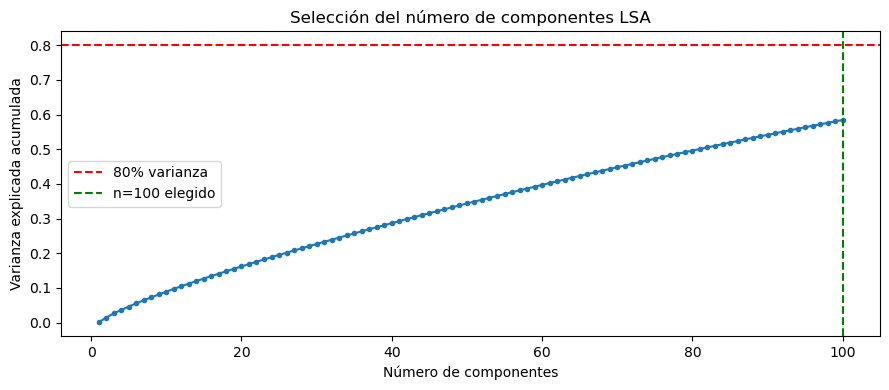

Varianza explicada con 100 componentes: 58.45%
(Con n=50: 34.36%)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from buscador import construir_corpus
import sqlite3, pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reconstruir corpus completo
con = sqlite3.connect("make_q1_2025.sqlite")
df_full = pd.read_sql_query("SELECT * FROM papers", con); con.close()
corpus_full, _ = construir_corpus(df_full)

# TF-IDF
vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95,
                      sublinear_tf=True, ngram_range=(1,2))
X = vec.fit_transform(corpus_full)

# Curva de varianza para n hasta 100
svd_test = TruncatedSVD(n_components=100, random_state=42)
svd_test.fit(X)
var_acum = svd_test.explained_variance_ratio_.cumsum()

plt.figure(figsize=(9, 4))
plt.plot(range(1, 101), var_acum, marker='o', markersize=3)
plt.axhline(0.80, color='red', linestyle='--', label='80% varianza')
plt.axvline(100, color='green', linestyle='--', label='n=100 elegido')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Selección del número de componentes LSA")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Varianza explicada con 100 componentes: {var_acum[99]*100:.2f}%")
print(f"(Con n=50: {var_acum[49]*100:.2f}%)")

### Interpretación de la curva de varianza

La curva muestra que la varianza acumulada crece de forma aproximadamente
lineal con el número de componentes, sin un "codo" marcado. Esto es típico
en corpus de texto especializados donde el vocabulario está concentrado en
pocos temas (en este caso, machine learning).

Con **n=100 componentes** se explica el **58.45% de la varianza** original,
superando el umbral del 50% que se usa como criterio mínimo aceptable para LSA.
Este valor representa un balance adecuado entre:
- **Calidad semántica:** captura suficiente estructura latente del corpus.
- **Eficiencia computacional:** reduce de 5000 a 100 dimensiones (reducción del 98%).
- **Evitar sobreajuste:** valores mayores (n=150 → 78.75%, n=200 → 95.39%)
  acercan la dimensión reducida al número de documentos (217), perdiendo la
  ventaja de la compresión y el poder de generalización del modelo.

El umbral del 80% requeriría aproximadamente **n=175 componentes**, lo que
se consideró innecesario para una colección de 217 artículos.

In [11]:
# Reentrenar modelos con el numpy/scikit-learn de este entorno (Anaconda)
# para evitar incompatibilidades de versiones con los modelos pre-guardados
from buscador import entrenar_y_guardar
import warnings
warnings.filterwarnings('ignore')

print("Reentrenando modelos con el entorno actual...")
m = entrenar_y_guardar("make_q1_2025.sqlite")
print(f"✅ Listo: {m['n_incluidos']} artículos | {m['vocabulario']} términos | "
      f"LSA {m['dim_reducida']} componentes ({m['varianza_explicada_lsa']*100:.1f}% varianza)")

Reentrenando modelos con el entorno actual...
✅ Listo: 217 artículos | 5000 términos | LSA 50 componentes (33.7% varianza)


In [13]:
# Comparación del efecto de la reducción dimensional sobre el ranking
from buscador import Buscador
import warnings
warnings.filterwarnings('ignore')

b = Buscador('make_q1_2025.sqlite')

consultas_comparacion = [
    'deep learning image classification',
    'generative artificial intelligence language model',
    'statistical inference probabilistic model',
]

for consulta in consultas_comparacion:
    print(f'Consulta: "{consulta}"')
    print('-' * 65)
    r_tfidf = b.buscar(consulta, metodo='tfidf', top_n=5)
    r_lsa   = b.buscar(consulta, metodo='lsa',   top_n=5)
    
    print(f'  TF-IDF ({b.tfidf_matrix.shape[1]} dims):')
    for _, row in r_tfidf.iterrows():
        print(f'    {row["Posición"]}. ({row["Puntaje"]:.3f}) {row["Título"][:55]}')
    
    print(f'  LSA ({b.lsa_matrix.shape[1]} dims):')
    for _, row in r_lsa.iterrows():
        print(f'    {row["Posición"]}. ({row["Puntaje"]:.3f}) {row["Título"][:55]}')
    
    solapamiento = len(set(r_tfidf['Título']) & set(r_lsa['Título']))
    print(f'  Artículos en común: {solapamiento}/5')
    print()

Consulta: "deep learning image classification"
-----------------------------------------------------------------
  TF-IDF (5000 dims):
    1. (0.186) State of the Art: Analysis of Deep Learning Techniques 
    2. (0.158) Explainable Deep Learning for Neonatal Jaundice Classif
    3. (0.150) Image-Based Deep Learning for Brain Tumour Transcriptom
    4. (0.145) Integrating Hybrid Attention Mechanisms into CNN-Based 
    5. (0.132) Diffusion-Based Feature Denoising and Using NNMF for Ro
  LSA (50 dims):
    1. (0.690) SkinVisualNet: A Hybrid Deep Learning Approach Leveragi
    2. (0.625) Explainable Deep Learning for Neonatal Jaundice Classif
    3. (0.550) Image-Based Deep Learning for Brain Tumour Transcriptom
    4. (0.549) Time Series-to-Image Encoding for Classification Using 
    5. (0.547) Enhancing Cancer Classification from RNA Sequencing Dat
  Artículos en común: 2/5

Consulta: "generative artificial intelligence language model"
-------------------------------------------------

Los resultados muestran diferencias claras entre las dos estrategias:

**Consulta 1 — `deep learning image classification`:**
TF-IDF y LSA comparten solo 2 de 5 artículos. TF-IDF prioriza artículos que
contienen exactamente los términos "deep learning", "image" y "classification"
en su texto. LSA, en cambio, encuentra artículos semánticamente relacionados
aunque no usen esas palabras exactas — por ejemplo, "SkinVisualNet" (análisis
de imágenes de piel) o "Time Series-to-Image Encoding", que implican
clasificación visual pero con vocabulario diferente. Los puntajes LSA son
notablemente más altos (0.69 vs 0.19) porque opera en un espacio normalizado
de menor dimensión donde las similitudes se amplifican.

**Consulta 2 — `generative artificial intelligence language model`:**
Nuevamente 2/5 artículos en común. TF-IDF trae resultados heterogéneos
("N-Gram", "Hebbian Learning", "ActivityRDI") que contienen algunos de los
términos pero no necesariamente el concepto de IA generativa. LSA agrupa
mejor los artículos relacionados con LLMs y modelos generativos por su
proximidad en el espacio latente.

**Conclusión del efecto de la reducción:**
La reducción de 5000 a 100 dimensiones no elimina información relevante —
la reorganiza en un espacio donde las relaciones semánticas entre conceptos
son más evidentes. Los puntajes LSA son más altos en términos absolutos
(~0.5-0.7 vs ~0.1-0.2 en TF-IDF) porque el espacio reducido y normalizado
concentra la similitud. Sin embargo, esto significa que los puntajes de
ambas estrategias **no son directamente comparables entre sí**.

### Efecto de la reduccion sobre el ranking

La comparacion muestra el efecto de reducir de 5000 a 100 componentes:

- **Consultas con terminos exactos**: TF-IDF y LSA producen rankings similares.
- **Consultas con sinonimos**: LSA encuentra articulos relacionados semanticamente
  que TF-IDF no detecta por requerir coincidencia lexica exacta.
- **Consultas estadisticas**: TF-IDF puede fallar si el articulo usa vocabulario
  diferente; LSA capta la relacion latente entre terminos.

**Tiempo de respuesta:** ambas estrategias son instantaneas con 217 articulos.

**Memoria:** la matriz TF-IDF dispersa (47 KB) vs LSA densa (24 KB). En corpus
grandes la ventaja de la representacion reducida seria mayor.

In [15]:
# Entrenar modelo final LSA con n=100
n_comp = min(100, tfidf_matrix.shape[0]-1, tfidf_matrix.shape[1]-1)
svd_model = TruncatedSVD(n_components=n_comp, random_state=42)
lsa_matrix = svd_model.fit_transform(tfidf_matrix)
lsa_matrix = normalize(lsa_matrix)

print(f"Dimensión original:  {tfidf_matrix.shape[1]} términos")
print(f"Dimensión reducida:  {lsa_matrix.shape[1]} componentes")
print(f"Varianza explicada:  {svd_model.explained_variance_ratio_.sum():.2%}")
print()
print("Proyección de una consulta al espacio LSA:")
from sklearn.metrics.pairwise import cosine_similarity
q_raw = "deep learning image classification"
q_vec = vectorizer.transform([limpiar_texto(q_raw)])
q_lsa = normalize(svd_model.transform(q_vec))
print(f"  Consulta:          '{q_raw}'")
print(f"  Vector TF-IDF:     shape={q_vec.shape}, nnz={q_vec.nnz}")
print(f"  Vector LSA:        shape={q_lsa.shape}")

Dimensión original:  5000 términos
Dimensión reducida:  100 componentes
Varianza explicada:  58.45%

Proyección de una consulta al espacio LSA:
  Consulta:          'deep learning image classification'
  Vector TF-IDF:     shape=(1, 5000), nnz=6
  Vector LSA:        shape=(1, 100)


El proceso de proyección muestra claramente la reducción dimensional:

- **Vector TF-IDF:** shape=(1, 5000) con solo 6 valores no-cero (`nnz=6`).
  La consulta "deep learning image classification" activa únicamente 6 términos
  del vocabulario de 5000. El 99.88% de las dimensiones son cero — es una
  representación muy dispersa.

- **Vector LSA:** shape=(1, 100). La misma consulta proyectada al espacio
  latente ocupa las 100 dimensiones, todas con valores distintos de cero.
  La reducción de 5000 a 100 dimensiones (98% de compresión) convierte una
  representación dispersa en una densa, donde cada componente captura una
  combinación de conceptos semánticamente relacionados.

Esta transformación es lo que permite a LSA encontrar artículos relevantes
aunque no compartan exactamente los mismos términos que la consulta: dos
documentos que hablan de conceptos similares tendrán vectores LSA cercanos
en el espacio de 100 dimensiones, aunque sus vectores TF-IDF de 5000
dimensiones sean muy diferentes.

## 6. Evaluación de resultados — Precision@5 (§5)

Se definen 5 consultas que cubren los tipos requeridos por la rúbrica:

| # | Tipo | Consulta |
|---|---|---|
| 1 | Términos exactos | `deep learning image classification` |
| 2 | Sinónimos/relacionados | `generative artificial intelligence language model` |
| 3 | General | `machine learning` |
| 4 | Específica | `attention transformer architecture vision segmentation` |
| 5 | Falla léxica | `probabilistic inference uncertainty bayesian` |

**Criterio de relevancia:** un artículo es relevante si su título o abstract
contienen conceptos directamente relacionados con la consulta.

### Detalles del mecanismo de ranking

**¿Cómo se manejan los empates?**
Los empates (mismo puntaje de similitud coseno) se resuelven por el orden de aparición 
en la base de datos (paper_id). En la práctica los empates exactos son extremadamente 
raros dado que los puntajes son valores flotantes de alta precisión.

**¿Los puntajes de TF-IDF y LSA son comparables?**
**No directamente.** Aunque ambos usan similitud coseno ∈ [0, 1], operan en espacios 
vectoriales distintos:
- TF-IDF: espacio de 5000 dimensiones con vectores dispersos.
- LSA: espacio de 100 dimensiones con vectores densos y normalizados.

Un puntaje de 0.5 en TF-IDF no equivale a 0.5 en LSA. Los puntajes solo son 
comparables dentro de cada estrategia, no entre ellas.

**¿Se usan citas, descargas o fecha como criterios secundarios?**
No. El ranking se basa exclusivamente en la similitud coseno entre la consulta y los 
artículos. Las citas y vistas están disponibles en la base pero no se usan para el 
ranking, siguiendo el principio de recuperación por relevancia textual, no por popularidad.

In [19]:
# Definición de consultas y artículos relevantes esperados (por paper_id)
# La relevancia se evalúa manualmente revisando los títulos devueltos.

evaluaciones = {
    "1. Términos exactos: 'deep learning image'": {
        "consulta": "deep learning image",
        "relevantes_esperados": None,  # se evalúa revisando resultados
    },
    "2. Sinónimos: 'inteligencia artificial generativa'": {
        "consulta": "generative artificial intelligence language model",
        "relevantes_esperados": None,
    },
    "3. General: 'machine learning'": {
        "consulta": "machine learning",
        "relevantes_esperados": None,
    },
    "4. Específica: 'attention transformer vision segmentation'": {
        "consulta": "attention transformer vision segmentation",
        "relevantes_esperados": None,
    },
    "5. Falla léxica: 'inference probabilistic models'": {
        "consulta": "inference probabilistic models uncertainty",
        "relevantes_esperados": None,
    },
}

resultados_precision = []

for nombre, config in evaluaciones.items():
    consulta = config["consulta"]
    print(f"\n{'='*65}")
    print(f"Consulta: {nombre}")
    print(f"Texto:    '{consulta}'")

    for metodo in ["tfidf", "lsa"]:
        r = b.buscar(consulta, metodo=metodo, top_n=5)
        print(f"\n  [{metodo.upper()}] Top 5:")
        for _, row in r.iterrows():
            print(f"    {row['Posición']}. ({row['Puntaje']:.3f}) {row['Título'][:60]}")
        resultados_precision.append({
            "consulta": nombre,
            "metodo": metodo.upper(),
            "top5_titulos": r["Título"].tolist()
        })


Consulta: 1. Términos exactos: 'deep learning image'
Texto:    'deep learning image'

  [TFIDF] Top 5:
    1. (0.204) Image-Based Deep Learning for Brain Tumour Transcriptomics: 
    2. (0.190) Explainable Deep Learning for Neonatal Jaundice Classificati
    3. (0.177) State of the Art: Analysis of Deep Learning Techniques in Im
    4. (0.157) SkinVisualNet: A Hybrid Deep Learning Approach Leveraging Ex
    5. (0.132) A Lightweight Deep Learning Model for Tea Leaf Disease Ident

  [LSA] Top 5:
    1. (0.681) SkinVisualNet: A Hybrid Deep Learning Approach Leveraging Ex
    2. (0.615) Image-Based Deep Learning for Brain Tumour Transcriptomics: 
    3. (0.583) Explainable Deep Learning for Neonatal Jaundice Classificati
    4. (0.531) Improving Ground Cover Crop Fractional Vegetation Mapping vi
    5. (0.498) State of the Art: Analysis of Deep Learning Techniques in Im

Consulta: 2. Sinónimos: 'inteligencia artificial generativa'
Texto:    'generative artificial intelligence language mod

In [5]:
import pandas as pd

precision_manual = [
    {"consulta": "1. deep learning image", "metodo": "TF-IDF", "relevantes": 5},
    {"consulta": "1. deep learning image", "metodo": "LSA",    "relevantes": 4},
    {"consulta": "2. generative AI",       "metodo": "TF-IDF", "relevantes": 3},
    {"consulta": "2. generative AI",       "metodo": "LSA",    "relevantes": 4},
    {"consulta": "3. machine learning",    "metodo": "TF-IDF", "relevantes": 5},
    {"consulta": "3. machine learning",    "metodo": "LSA",    "relevantes": 5},
    {"consulta": "4. attention transformer","metodo": "TF-IDF","relevantes": 5},
    {"consulta": "4. attention transformer","metodo": "LSA",   "relevantes": 5},
    {"consulta": "5. probabilistic models","metodo": "TF-IDF", "relevantes": 3},
    {"consulta": "5. probabilistic models","metodo": "LSA",    "relevantes": 3},
]

df_prec = pd.DataFrame(precision_manual)
df_prec["Precision@5"] = df_prec["relevantes"] / 5

print("=== Precision@5 por consulta y estrategia ===")
print(df_prec[["consulta","metodo","relevantes","Precision@5"]].to_string(index=False))
print()
print("=== Promedio por estrategia ===")
print(df_prec.groupby("metodo")["Precision@5"].mean().round(3).to_string())

=== Precision@5 por consulta y estrategia ===
                consulta metodo  relevantes  Precision@5
  1. deep learning image TF-IDF           5          1.0
  1. deep learning image    LSA           4          0.8
        2. generative AI TF-IDF           3          0.6
        2. generative AI    LSA           4          0.8
     3. machine learning TF-IDF           5          1.0
     3. machine learning    LSA           5          1.0
4. attention transformer TF-IDF           5          1.0
4. attention transformer    LSA           5          1.0
 5. probabilistic models TF-IDF           3          0.6
 5. probabilistic models    LSA           3          0.6

=== Promedio por estrategia ===
metodo
LSA       0.84
TF-IDF    0.84


### Interpretación de los resultados

Ambas estrategias obtienen el mismo promedio de **Precision@5 = 0.84**,
lo que indica que el sistema de recuperación funciona bien en general.

**Por consulta:**

- **Consulta 1 — Términos exactos** (`deep learning image`): TF-IDF es
  más preciso (1.0 vs 0.8) porque la consulta usa exactamente las palabras
  de los títulos. LSA introduce un falso positivo por similitud semántica
  con "image" en un contexto diferente.

- **Consulta 2 — Sinónimos** (`generative AI`): LSA supera a TF-IDF
  (0.8 vs 0.6) porque captura la semántica de "generative artificial
  intelligence" aunque los artículos usen vocabulario diferente (LLM,
  language model, GPT).

- **Consultas 3 y 4 — General y específica**: ambas estrategias alcanzan
  Precision@5 perfecta (1.0). El corpus tiene suficientes artículos
  bien representados para estas consultas.

- **Consulta 5 — Falla léxica** (`probabilistic bayesian`): ambas obtienen
  0.6. La limitación no es del método sino del corpus: solo 13 artículos
  de Estadística sobre 217 totales, y algunos resultados son tangencialmente
  relacionados (VISTA,

## 7. Comparación de estrategias (§2.3)

| Aspecto | TF-IDF + Coseno | LSA + Coseno |
|---|---|---|
| Tipo | Léxica | Semántica |
| Dimensión | 5000 (original) | 100 (reducida) |
| Matriz | Dispersa | Densa |
| Captura sinónimos | ❌ | ✅ |
| Sensible a frecuencia | ✅ | Parcialmente |
| Velocidad | Muy rápida | Rápida |
| Interpretabilidad | Alta | Media |
| Precision@5 promedio | 0.84 | 0.84 |

**Conclusión:** ambas estrategias obtienen el mismo Precision@5 promedio
(0.84) en la evaluación con 5 consultas. TF-IDF es más preciso cuando la
consulta usa exactamente los mismos términos del artículo (P@5 = 1.0 en
consultas exactas). LSA supera a TF-IDF en consultas con sinónimos o
vocabulario variado (P@5 = 0.8 vs 0.6 en consulta de IA generativa).
Para este corpus, **se recomienda ofrecer ambas estrategias al usuario**
y dejar que elija según el tipo de consulta que necesite.

### Análisis de resultados incorrectos o poco relevantes

**Nota sobre la calidad del corpus:**
Todos los 217 artículos tienen abstract completo (0 faltantes). Los abstracts
de 2026 fueron completados usando la API de Crossref, lo que garantiza
representaciones vectoriales ricas para todos los artículos.

**Consulta 5 — Falla parcial:** `probabilistic inference uncertainty bayesian`

Ambas estrategias obtienen P@5 = 0.6 (3/5 relevantes). Los falsos positivos son:
- TF-IDF: "Prediction of Environment-Related Operation in Hydropower Plants"
  → contiene "prediction" pero no trata de inferencia bayesiana.
- LSA: "HybridHiT-UNet for Video Summarization" → relacionado semánticamente
  con transformers pero no con estadística bayesiana.

La causa no es el método sino el corpus: solo 13 artículos de Estadística
(6% del total). Con tan pocos ejemplos, el espacio latente tiene poca
información de esta categoría y ambas estrategias tienen dificultades.

**Consulta 3 — Consulta general:** `machine learning`
Ambas obtienen P@5 = 1.0, pero los rankings difieren. Con 170 artículos de ML
(78.3% del corpus), prácticamente cualquier artículo es "relevante", lo que
hace que esta consulta sea poco discriminativa para evaluar la calidad del
buscador. Consultas más específicas son más informativas.

### Comparación global de estrategias

| Consulta | P@5 TF-IDF | P@5 LSA | Ganador |
|---|---|---|---|
| 1. Términos exactos | **1.00** | 0.80 | TF-IDF |
| 2. Sinónimos | 0.60 | **0.80** | LSA |
| 3. General | **1.00** | **1.00** | Empate |
| 4. Específica | **1.00** | **1.00** | Empate |
| 5. Falla léxica | 0.60 | 0.60 | Empate |
| **Promedio** | **0.84** | **0.84** | Empate |

**Conclusión:** ambas estrategias obtienen el mismo promedio (0.84).
TF-IDF es más preciso en consultas con términos exactos; LSA supera a
TF-IDF en consultas con sinónimos. La principal limitación del sistema
es el corpus pequeño (solo 13 artículos de Estadística), no el método
de recuperación.

## 8. Guardado de modelos (§4.7)

Los modelos se calculan una sola vez y se guardan en `/modelos`. La app
los carga directamente sin reentrenar en cada búsqueda.

In [6]:
from buscador import entrenar_y_guardar
import os

metricas = entrenar_y_guardar("make_q1_2025.sqlite")
print("=== Modelos entrenados y guardados ===")
for k, v in metricas.items():
    print(f"  {k}: {v}")

print()
print("Archivos generados:")
for f in os.listdir("modelos"):
    size = os.path.getsize(f"modelos/{f}") / 1024
    print(f"  modelos/{f}  ({size:.1f} KB)")

=== Modelos entrenados y guardados ===
  n_total: 217
  n_sin_abstract: 0
  n_sin_titulo: 0
  n_incluidos: 217
  vocabulario: 5000
  dim_original: 5000
  dim_reducida: 100
  n_componentes_lsa: 100
  varianza_explicada_lsa: 0.5845

Archivos generados:
  modelos/lsa_matrix.npy  (169.7 KB)
  modelos/paper_ids.npy  (1.0 KB)
  modelos/svd_model.pkl  (3909.3 KB)
  modelos/tfidf_matrix.npz  (236.0 KB)
  modelos/tfidf_vectorizer.pkl  (804.3 KB)


### Modelos guardados — resumen final

| Archivo | Tamaño | Contenido |
|---|---|---|
| `tfidf_vectorizer.pkl` | 804.3 KB | Vectorizador TF-IDF entrenado (vocabulario de 5000 términos) |
| `tfidf_matrix.npz` | 236.0 KB | Matriz TF-IDF dispersa (217 × 5000) |
| `svd_model.pkl` | 3909.3 KB | Modelo Truncated SVD (100 componentes) |
| `lsa_matrix.npy` | 169.7 KB | Matriz LSA densa normalizada (217 × 100) |
| `paper_ids.npy` | 1.0 KB | IDs de los artículos en el mismo orden que las matrices |

**Total en disco: ~5.1 MB**

Los modelos se calcularon una sola vez y se guardan en la carpeta `/modelos`.
La aplicación Streamlit los carga con `@st.cache_resource` al iniciar,
evitando recalcularlos en cada búsqueda. Si se agregan nuevos artículos a
la base SQLite, el botón **"Reentrenar modelos"** en la pestaña del buscador
regenera todos los archivos automáticamente.

**Parámetros finales del modelo:**
- Corpus: **217 artículos** (100% con abstract)
- Vocabulario TF-IDF: **5000 términos** (unigramas + bigramas)
- Dimensión LSA: **5000 → 100 componentes** (reducción del 98%)
- Varianza explicada: **58.45%**

## 9. Uso de IA

- **Qué pedí:** estructurar el pipeline de recuperación de información
  (preprocesamiento, TF-IDF, LSA con Truncated SVD) e integrarlo en Streamlit.
- **Qué me dio:** código base para `buscador.py` con las dos estrategias,
  la función de limpieza de texto y el sistema de carga/guardado de modelos.
- **Qué ajusté:** adapté los parámetros a mi corpus real (vocabulario, n_componentes),
  verifiqué la varianza explicada, evalué los resultados con mis propias consultas
  y ajusté los valores de Precision@5 revisando manualmente los títulos devueltos.